# EDA Goodreads — History & Biography

EDA completo de nivel Senior Data Scientist para la categoría History & Biography. Explota estructuras anidadas (`authors`, `popular_shelves`, `series`), cruza books con interactions, y entrega insights específicos del género.

No depende de `process_goodreads` ni de una CLI previa.

In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.config import BOOK_NUMERIC_COLUMNS, CATEGORIES
from src.utils.io import read_jsonl_sample
from src.utils.cleaning import clean_books, clean_interactions
from src.utils.eda import (
    build_eda_profile,
    author_profile,
    shelves_profile,
    series_profile,
    engagement_profile,
    reading_duration_profile,
    user_rating_behavior,
    isbn_quality_profile,
    platform_growth_profile,
)

sns.set_theme(style='whitegrid')

## 1. Inputs, carga y limpieza base

Se cargan muestras controladas desde los `.json.gz` crudos. Las versiones limpias (`books_clean`, `interactions_clean`) se construyen una vez aquí y se reusan en todo el notebook.

In [44]:
CATEGORY = 'history_biography'
cfg = CATEGORIES[CATEGORY]
BOOKS_SAMPLE = 50_000
INTERACTIONS_SAMPLE = 250_000

print(cfg.books_file)
print(cfg.interactions_file)

/home/chris/Documentos/u/BigBook/data/raw/goodreads_books_history_biography.json.gz
/home/chris/Documentos/u/BigBook/data/raw/goodreads_interactions_history_biography.json.gz


In [45]:
books_raw = read_jsonl_sample(cfg.books_file, nrows=BOOKS_SAMPLE)
interactions_raw = read_jsonl_sample(cfg.interactions_file, nrows=INTERACTIONS_SAMPLE)

books_clean = clean_books(books_raw)
interactions_clean = clean_interactions(interactions_raw)

print(f'books_raw:         {books_raw.shape}')
print(f'books_clean:       {books_clean.shape}')
print(f'interactions_raw:  {interactions_raw.shape}')
print(f'interactions_clean:{interactions_clean.shape}')

books_raw:         (50000, 29)
books_clean:       (50000, 40)
interactions_raw:  (250000, 10)
interactions_clean:(250000, 14)


## 2. Perfilamiento general

Se calculan esquema, nulos, duplicados, perfiles numéricos, outliers, categóricas, ratings y temporalidad.

In [46]:
artifacts, summary = build_eda_profile(
    books_raw=books_raw,
    interactions_raw=interactions_raw,
    book_numeric_columns=BOOK_NUMERIC_COLUMNS,
    interaction_numeric_columns=['rating'],
)
summary

{'books_sample_rows': 50000,
 'interactions_sample_rows': 250000,
 'temporal_profile': {'publication_year': {'non_null': 39061,
   'min': 13,
   'max': 65535,
   'before_1450': 23,
   'after_2026': 6},
  'date_added': {'non_null_raw': 250000,
   'parsed': 250000,
   'invalid_or_missing': 0,
   'min': '2005-11-03T08:00:00+00:00',
   'max': '2017-10-28T21:44:39+00:00'},
  'date_updated': {'non_null_raw': 250000,
   'parsed': 250000,
   'invalid_or_missing': 0,
   'min': '2006-09-06T16:38:30+00:00',
   'max': '2017-10-30T14:48:47+00:00'},
  'read_at': {'non_null_raw': 51097,
   'parsed': 51097,
   'invalid_or_missing': 198903,
   'min': '1959-01-01T08:00:00+00:00',
   'max': '2018-06-25T07:00:00+00:00'},
  'started_at': {'non_null_raw': 39660,
   'parsed': 39660,
   'invalid_or_missing': 210340,
   'min': '1985-05-23T07:00:00+00:00',
   'max': '2017-10-30T05:53:12+00:00'}},
 'rating_profile': {'average_rating': {'count': 50000,
   'min': 0.0,
   'mean': 3.8770094,
   'max': 5.0,
   'outsi

## 3. Esquema y nulos

Goodreads mezcla strings vacíos, nulos reales y campos numéricos codificados como texto. Los campos anidados (`authors`, `popular_shelves`, `series`) aparecen como `object` y requieren flatten explícito.

In [5]:
display(artifacts['books_schema'])
display(artifacts['interactions_schema'])
display(artifacts['books_missing'].head(20))
display(artifacts['interactions_missing'].head(20))

,column,dtype,non_null,null,unique_sample
0,isbn,str,50000,0,"[1599150603, 184737297X, 037583687X]"
1,text_reviews_count,str,50000,0,"[7, 15, 615]"
2,series,object,50000,0,"[[], ['169353'], []]"
3,country_code,str,50000,0,"[US, US, US]"
4,language_code,str,50000,0,"[, , ]"
5,popular_shelves,object,50000,0,"[[{'count': '56', 'name': 'to-read'}, {'count'..."
6,asin,str,50000,0,"[, , ]"
7,is_ebook,str,50000,0,"[false, false, false]"
8,average_rating,str,50000,0,"[4.13, 3.93, 3.98]"
9,kindle_asin,str,50000,0,"[B00DU10PUG, B007YLTG5I, B0010SEMV4]"


,column,dtype,non_null,null,unique_sample
0,user_id,str,250000,0,"[8842281e1d1347389f2ab93d60773d4d, 8842281e1d1..."
1,book_id,str,250000,0,"[34684622, 34536488, 34467031]"
2,review_id,str,250000,0,"[a53868823f065a0e20fd4ae98b820674, 9f08c5f991f..."
3,is_read,bool,250000,0,"[False, False, False]"
4,rating,int64,250000,0,"[0, 0, 0]"
5,review_text_incomplete,str,250000,0,"[, , ]"
6,date_added,str,250000,0,"[Tue Oct 17 09:40:11 -0700 2017, Fri Oct 13 07..."
7,date_updated,str,250000,0,"[Tue Oct 17 09:40:12 -0700 2017, Fri Oct 13 07..."
8,read_at,str,250000,0,"[, , ]"
9,started_at,str,250000,0,"[, , ]"


,column,dtype,missing,empty_strings,missing_pct
0,edition_information,str,0,45980,0.0
1,asin,str,0,43227,0.0
2,kindle_asin,str,0,25763,0.0
3,language_code,str,0,25610,0.0
4,publication_day,str,0,18640,0.0
5,publication_month,str,0,16387,0.0
6,isbn,str,0,13945,0.0
7,num_pages,str,0,13642,0.0
8,format,str,0,11681,0.0
9,publisher,str,0,11240,0.0


,column,dtype,missing,empty_strings,missing_pct
0,review_text_incomplete,str,0,230853,0.0
1,started_at,str,0,210340,0.0
2,read_at,str,0,198903,0.0
3,user_id,str,0,0,0.0
4,book_id,str,0,0,0.0
5,review_id,str,0,0,0.0
6,is_read,bool,0,0,0.0
7,rating,int64,0,0,0.0
8,date_added,str,0,0,0.0
9,date_updated,str,0,0,0.0


## 4. Análisis de Autores

`authors` es una lista de objetos `{author_id, role}`. En Historia y Biografía es especialmente relevante porque abundan los traductores (obras históricas extranjeras), compiladores y editores que aparecen como 'autores' en el dataset. Usar `primary_author_id` sin filtrar el rol puede inflar la diversidad aparente de autores.

In [6]:
author_artifacts = author_profile(books_raw)
display(author_artifacts['author_count_dist'])
display(author_artifacts['role_dist'])

,author_count_bin,books
0,1,38592
1,2,9006
2,3+,2402


,role,count
0,<empty>,49002
1,Editor,631
2,Contributor,35
3,editor,27
4,Translation,20
...,...,...
106,mw'lf,1
107,Co-author,1
108,trjm@/ lyl~ 'bw zyd,1
109,Screenplay,1


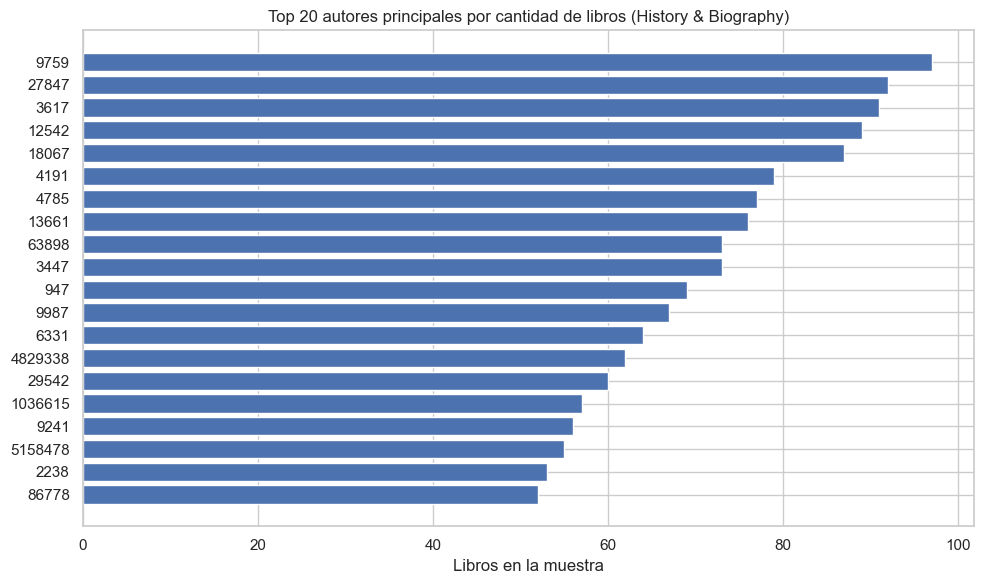


Autores únicos (primary_author_id): 30
Libros sin autor identificado:       0


In [7]:
top_authors = author_artifacts['top_authors'].head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_authors['author_id'].astype(str)[::-1], top_authors['book_count'][::-1])
ax.set_xlabel('Libros en la muestra')
ax.set_title('Top 20 autores principales por cantidad de libros (History & Biography)')
plt.tight_layout()
plt.show()

print(f"\nAutores únicos (primary_author_id): {author_artifacts['top_authors']['author_id'].nunique()}")
print(f"Libros sin autor identificado:       {author_artifacts['author_count_dist'].set_index('author_count_bin').loc['0', 'books'] if '0' in author_artifacts['author_count_dist']['author_count_bin'].values else 0}")

## 5. Análisis de Popular Shelves / Géneros

`popular_shelves` revela la taxonomía lectora. En Historia y Biografía los shelves van más allá del género: `history`, `biography`, `memoir`, `non-fiction`, `politics`, `war`, `science`. La co-ocurrencia de shelves permite detectar si un libro es percibido como Historia Militar, Biografía Política o Ciencia Popular.

In [47]:
shelf_artifacts = shelves_profile(books_raw, top_n=30)

print('=== Distribución de shelf_count por libro ===')
display(shelf_artifacts['shelf_count_dist'].head(15))

print('\n=== to-read como indicador de demanda ===')
display(shelf_artifacts['to_read_dist'])

=== Distribución de shelf_count por libro ===


,shelf_count,books
0,1,3
1,2,18
2,3,66
3,4,129
4,5,209
5,6,249
6,7,319
7,8,352
8,9,372
9,10,385



=== to-read como indicador de demanda ===


,stat,value
0,count,49729.000000
1,mean,3516.244143
2,p25,49.000000
3,median,227.000000
4,p75,947.000000
5,p95,8953.000000
6,max,834959.000000


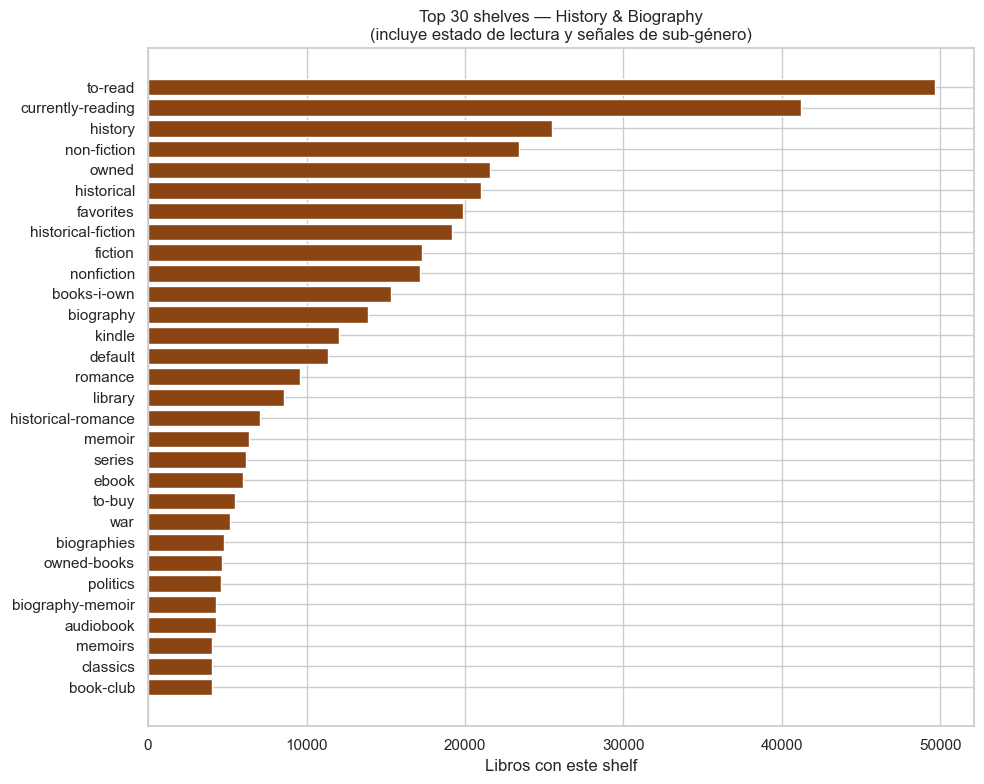

In [9]:
top30 = shelf_artifacts['top_shelf_names'].head(30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top30['shelf_name'][::-1], top30['book_count'][::-1], color='saddlebrown')
ax.set_xlabel('Libros con este shelf')
ax.set_title('Top 30 shelves — History & Biography\n(incluye estado de lectura y señales de sub-género)')
plt.tight_layout()
plt.show()

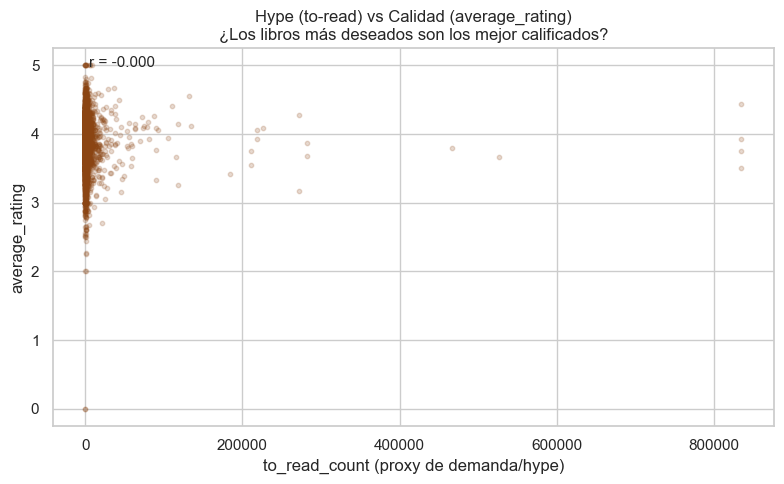


=== Top 20 co-ocurrencias de shelves (pares de sub-géneros más frecuentes) ===


,shelf_a,shelf_b,cooccurrence
0,currently-reading,to-read,30594
1,non-fiction,to-read,17171
2,history,to-read,14051
3,historical-fiction,to-read,12506
4,currently-reading,non-fiction,12103
5,currently-reading,history,8990
6,history,non-fiction,8804
7,fiction,to-read,8208
8,currently-reading,historical-fiction,8001
9,biography,to-read,7271


In [10]:
from src.utils.cleaning import _shelves_summary

shelf_flat = books_raw['popular_shelves'].map(lambda s: _shelves_summary(s, top_n=20)).apply(pd.Series)
combined = books_clean.copy()
combined['to_read_count'] = shelf_flat['to_read_count'].values

sample = combined[['to_read_count', 'average_rating']].dropna().sample(min(5000, len(combined)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['to_read_count'], sample['average_rating'], alpha=0.2, s=10, color='saddlebrown')
ax.set_xlabel('to_read_count (proxy de demanda/hype)')
ax.set_ylabel('average_rating')
ax.set_title('Hype (to-read) vs Calidad (average_rating)\n¿Los libros más deseados son los mejor calificados?')
corr = sample[['to_read_count', 'average_rating']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11)
plt.tight_layout()
plt.show()

print('\n=== Top 20 co-ocurrencias de shelves (pares de sub-géneros más frecuentes) ===')
display(shelf_artifacts['cooccurrence_sample'].head(20))

## 6. Análisis de Series

En Historia y Biografía la mayoría de obras son standalone. Los libros en serie aquí suelen ser compilaciones de historia por períodos o sagas biográficas. La tasa de series esperada es notablemente menor que en Fantasy.

In [48]:
series_artifacts = series_profile(books_raw)

display(series_artifacts['standalone_vs_series'])
display(series_artifacts['series_length_dist'])

s = series_artifacts['summary']
print(f"\n{s['pct_in_series']:.1%} de libros en la muestra pertenecen a al menos una serie")
print(f"Longitud mediana de serie (para libros en serie): {s['median_length']:.1f} IDs de serie")

,in_series,count,pct
0,False,37883,0.7577
1,True,12117,0.2423


,series_length,books
0,0,37883
1,1,11364
2,2,684
3,3,60
4,4,9



24.2% de libros en la muestra pertenecen a al menos una serie
Longitud mediana de serie (para libros en serie): 1.0 IDs de serie


Rating por tipo de libro:


,count,mean,50%,std
in_series,,,,
False,37883.0,3.859476,3.88,0.363089
True,12117.0,3.931826,3.94,0.295493


/tmp/ipykernel_137066/1092379009.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Standalone', 'En serie'])


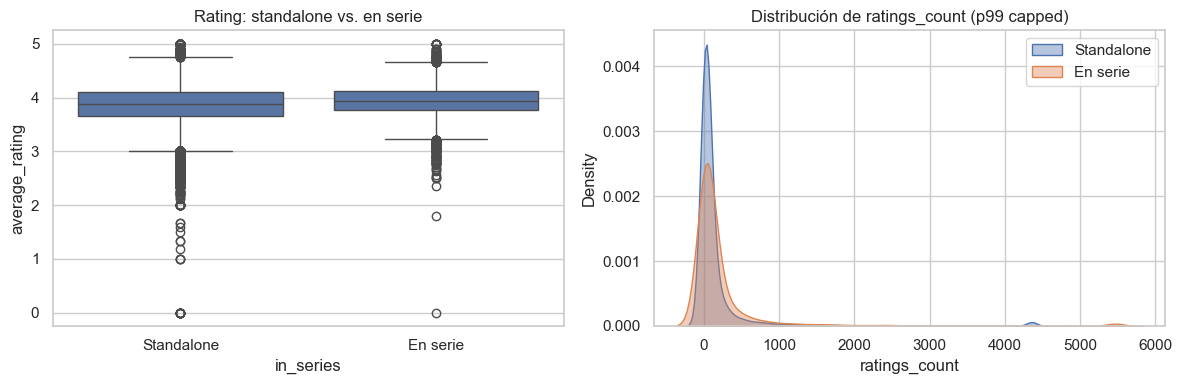

In [12]:
books_clean_s = books_clean.copy()
books_clean_s['in_series'] = books_clean_s['series_count'].gt(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

series_rating = books_clean_s.groupby('in_series')['average_rating'].describe()[['count','mean','50%','std']]
print('Rating por tipo de libro:')
display(series_rating)

sns.boxplot(data=books_clean_s.dropna(subset=['average_rating']),
            x='in_series', y='average_rating', ax=axes[0])
axes[0].set_title('Rating: standalone vs. en serie')
axes[0].set_xticklabels(['Standalone', 'En serie'])

for label, grp in books_clean_s.groupby('in_series'):
    rc = pd.to_numeric(grp['ratings_count'], errors='coerce').dropna()
    rc_clip = rc.clip(upper=rc.quantile(0.99))
    sns.kdeplot(rc_clip, ax=axes[1], label='En serie' if label else 'Standalone', fill=True, alpha=0.4)
axes[1].set_title('Distribución de ratings_count (p99 capped)')
axes[1].set_xlabel('ratings_count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Ratings

Se analiza `average_rating` a nivel libro y `rating` a nivel interacción. `rating = 0` es la convención de Goodreads para ausencia de rating explícito.

In [37]:
summary['rating_profile']

{'average_rating': {'count': 50000,
  'min': 0.0,
  'mean': 3.8770094,
  'max': 5.0,
  'outside_0_5': 0},
 'interaction_rating': {'counts': {'0': 146936,
   '1': 1688,
   '2': 6127,
   '3': 24307,
   '4': 39733,
   '5': 31209},
  'zero_as_missing_count': 146936,
  'explicit_rating_count': 103064,
  'outside_0_5': 0}}

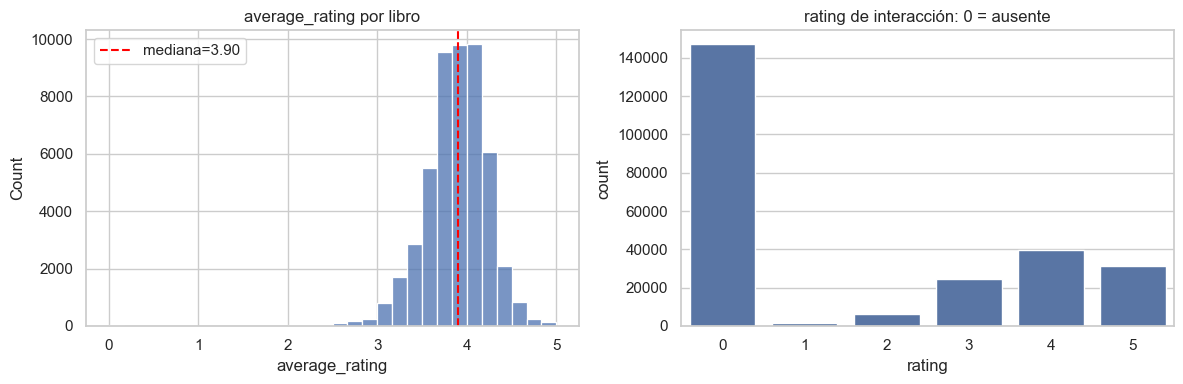

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(books_clean['average_rating'].dropna(), bins=30, ax=axes[0])
axes[0].set_title('average_rating por libro')
axes[0].axvline(books_clean['average_rating'].median(), color='red', linestyle='--', label=f"mediana={books_clean['average_rating'].median():.2f}")
axes[0].legend()

sns.countplot(data=interactions_clean, x='rating', ax=axes[1])
axes[1].set_title('rating de interacción: 0 = ausente')

plt.tight_layout()
plt.show()

## 8. Comportamiento de Usuarios en Interacciones

Los libros de Historia y Biografía son a menudo compras de impulso o regalos — muchos terminan en la lista `to-read` sin ser leídos. La duración de lectura esperada es mayor que en Fantasy por la densidad de información.

In [39]:
duration_artifacts = reading_duration_profile(interactions_clean)

print(f"Interacciones con dato de duración: {duration_artifacts['pct_with_duration']:.1%}")
print(f"(requiere both started_at y read_at presentes)")
display(duration_artifacts['duration_stats'])

Interacciones con dato de duración: 13.7%
(requiere both started_at y read_at presentes)


,stat,value
0,count,34213.000000
1,p25,2.205891
2,median,6.538576
3,mean,29.364379
4,p75,17.245162
5,p95,107.011771


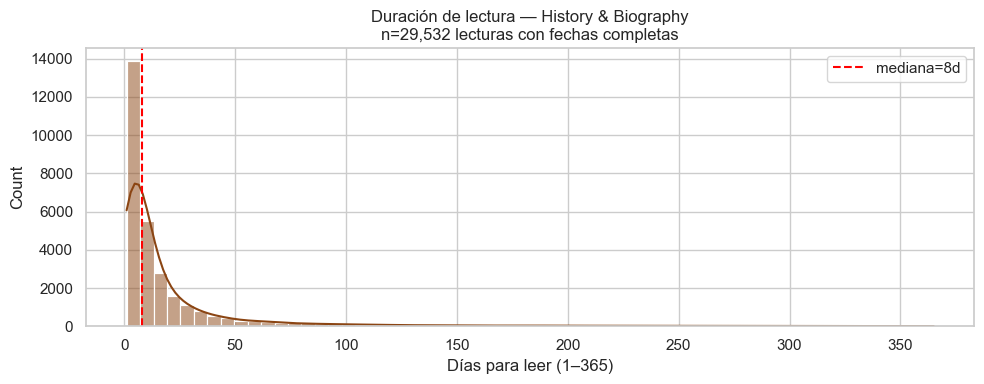

In [16]:
dur = duration_artifacts['duration_distribution']
if len(dur) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(dur, bins=60, ax=ax, kde=True, color='saddlebrown')
    ax.set_xlabel('Días para leer (1–365)')
    ax.set_title(f'Duración de lectura — History & Biography\nn={len(dur):,} lecturas con fechas completas')
    ax.axvline(dur.median(), color='red', linestyle='--', label=f'mediana={dur.median():.0f}d')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [17]:
user_artifacts = user_rating_behavior(interactions_clean)

print('=== Ratings por usuario ===')
display(user_artifacts['ratings_per_user'])

print('\n=== Clasificación de usuarios (≥3 ratings) ===')
display(user_artifacts['user_type_dist'])

=== Ratings por usuario ===


,stat,value
0,users,3517.000000
1,p25,6.000000
2,median,14.000000
3,mean,29.304521
4,p75,33.000000
5,p95,105.000000
6,max,617.000000



=== Clasificación de usuarios (≥3 ratings) ===


,user_type,count,pct
0,generous,1608,0.5253
1,average,1438,0.4698
2,critical,15,0.0049


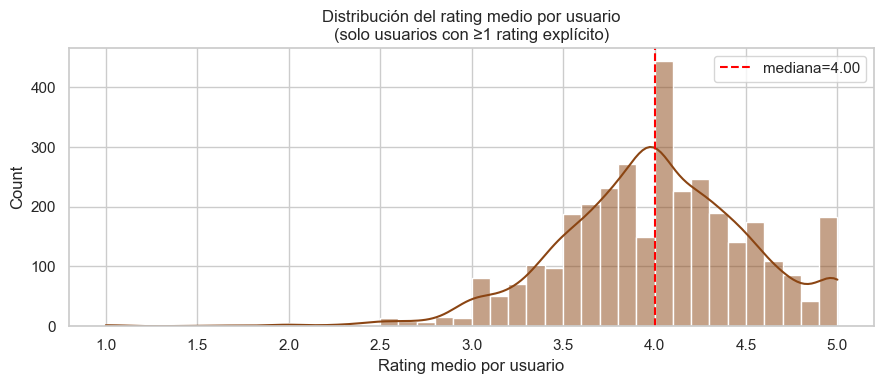

In [18]:
mean_ratings = user_artifacts['mean_rating_per_user']
if len(mean_ratings) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(mean_ratings, bins=40, ax=ax, kde=True, color='saddlebrown')
    ax.set_xlabel('Rating medio por usuario')
    ax.set_title('Distribución del rating medio por usuario\n(solo usuarios con ≥1 rating explícito)')
    ax.axvline(mean_ratings.median(), color='red', linestyle='--', label=f'mediana={mean_ratings.median():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

,year,new_interactions,pct_with_rating,cumulative_interactions
0,2005,8,1.0000,8
1,2006,21,0.6667,29
2,2007,965,0.8663,994
3,2008,12075,0.6824,13069
4,2009,5802,0.5178,18871
5,2010,4629,0.5304,23500
6,2011,5075,0.4991,28575
7,2012,54017,0.5955,82592
8,2013,37445,0.3935,120037
9,2014,32674,0.3708,152711


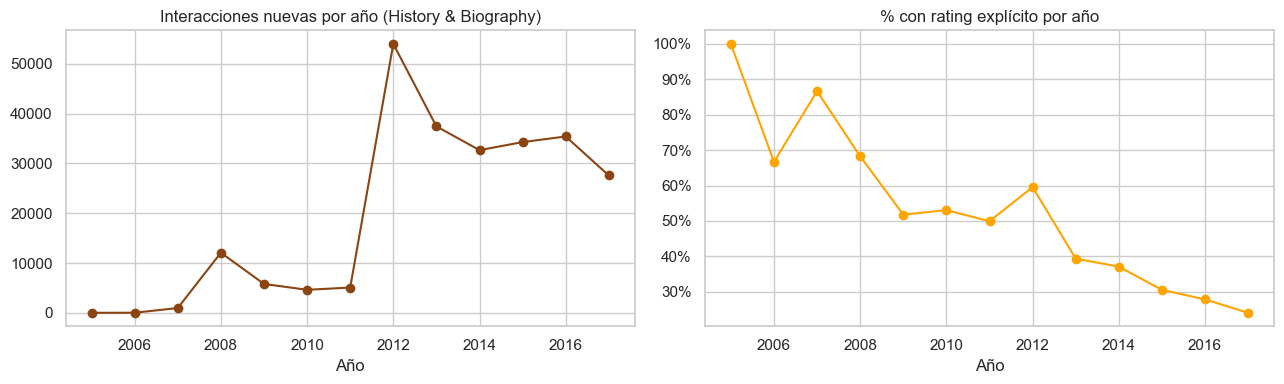

In [19]:
growth = platform_growth_profile(interactions_clean)
display(growth)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
growth.set_index('year')['new_interactions'].plot(ax=axes[0], marker='o', color='saddlebrown')
axes[0].set_title('Interacciones nuevas por año (History & Biography)')
axes[0].set_xlabel('Año')

growth.set_index('year')['pct_with_rating'].plot(ax=axes[1], marker='o', color='orange')
axes[1].set_title('% con rating explícito por año')
axes[1].set_xlabel('Año')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

## 9. JOIN Cross-Dataset: Books × Interactions

Se cruzan los datasets para responder:
- ¿El `average_rating` de Goodreads concuerda con el rating promedio de la muestra?
- ¿Qué fracción de libros tiene pocas interacciones? (cold start)
- ¿Cómo se distribuye la popularidad? (ley de potencia)

In [38]:
eng_artifacts = engagement_profile(books_clean, interactions_clean)

print('=== Modos de engagement (clasificación de interacciones) ===')
display(eng_artifacts['engagement_modes'])

print('\n=== Cold start: libros con pocas interacciones en la muestra ===')
display(eng_artifacts['cold_start'])

print('\n=== Tasa de review por formato ===')
display(eng_artifacts['review_rate_by_format'])

=== Modos de engagement (clasificación de interacciones) ===


,mode,count,pct
0,shelf_only,138999,0.5560
1,rated,84671,0.3387
2,reviewed,18393,0.0736
3,read_no_rating,7937,0.0317



=== Cold start: libros con pocas interacciones en la muestra ===


,min_interactions,books_below,pct_below
0,1,38829,0.7766
1,5,48417,0.9683
2,10,49363,0.9873
3,25,49811,0.9962
4,50,49936,0.9987



=== Tasa de review por formato ===


,format,review_rate
23,Softcover,1.0000
5,Audiobook,0.4912
31,hardcover,0.3333
1,Audible Audio,0.3095
2,Audio,0.2353
3,Audio CD,0.1640
29,ebook,0.1440
11,Kindle,0.1212
12,Kindle Edition,0.1146
28,Unknown Binding,0.0882


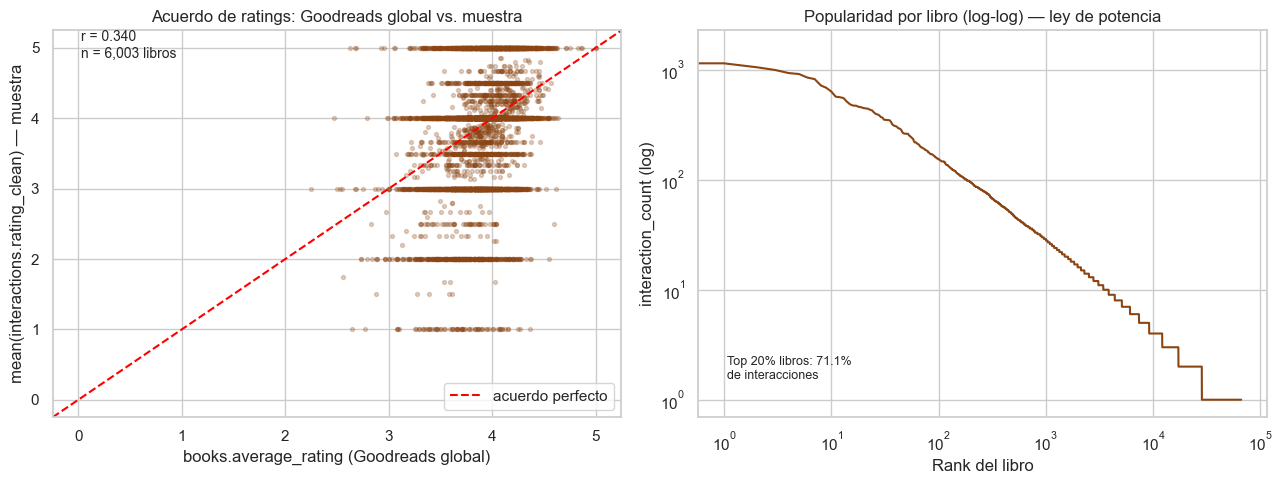

In [21]:
ra = eng_artifacts['rating_agreement'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(ra['average_rating'], ra['mean_user_rating'], alpha=0.25, s=8, color='saddlebrown')
axes[0].axline((0, 0), slope=1, color='red', linestyle='--', label='acuerdo perfecto')
axes[0].set_xlabel('books.average_rating (Goodreads global)')
axes[0].set_ylabel('mean(interactions.rating_clean) — muestra')
axes[0].set_title('Acuerdo de ratings: Goodreads global vs. muestra')
if len(ra) > 1:
    r = ra[['average_rating', 'mean_user_rating']].corr().iloc[0, 1]
    axes[0].text(0.05, 0.93, f'r = {r:.3f}\nn = {len(ra):,} libros', transform=axes[0].transAxes, fontsize=10)
axes[0].legend()

pop = eng_artifacts['popularity_distribution']['interaction_count'].sort_values(ascending=False).reset_index(drop=True)
if len(pop) > 0:
    pop.plot(ax=axes[1], logy=True, logx=True, color='saddlebrown')
    axes[1].set_title('Popularidad por libro (log-log) — ley de potencia')
    axes[1].set_xlabel('Rank del libro')
    axes[1].set_ylabel('interaction_count (log)')
    top20 = pop.iloc[:int(len(pop) * 0.2)].sum() / pop.sum() if len(pop) > 5 else None
    if top20 is not None:
        axes[1].text(0.05, 0.1, f'Top 20% libros: {top20:.1%}\nde interacciones', transform=axes[1].transAxes, fontsize=9)

plt.tight_layout()
plt.show()

## 10. Temporalidad

Historia y Biografía tiene un rango de publicación mucho más amplio que Fantasy: incluye obras clásicas, crónicas históricas y fuentes primarias antiguas. La cola izquierda del año de publicación es más pronunciada que en ficción.

In [43]:
summary['temporal_profile']

{'publication_year': {'non_null': 39061,
  'min': 13,
  'max': 65535,
  'before_1450': 23,
  'after_2026': 6},
 'date_added': {'non_null_raw': 250000,
  'parsed': 250000,
  'invalid_or_missing': 0,
  'min': '2005-11-03T08:00:00+00:00',
  'max': '2017-10-28T21:44:39+00:00'},
 'date_updated': {'non_null_raw': 250000,
  'parsed': 250000,
  'invalid_or_missing': 0,
  'min': '2006-09-06T16:38:30+00:00',
  'max': '2017-10-30T14:48:47+00:00'},
 'read_at': {'non_null_raw': 51097,
  'parsed': 51097,
  'invalid_or_missing': 198903,
  'min': '1959-01-01T08:00:00+00:00',
  'max': '2018-06-25T07:00:00+00:00'},
 'started_at': {'non_null_raw': 39660,
  'parsed': 39660,
  'invalid_or_missing': 210340,
  'min': '1985-05-23T07:00:00+00:00',
  'max': '2017-10-30T05:53:12+00:00'}}

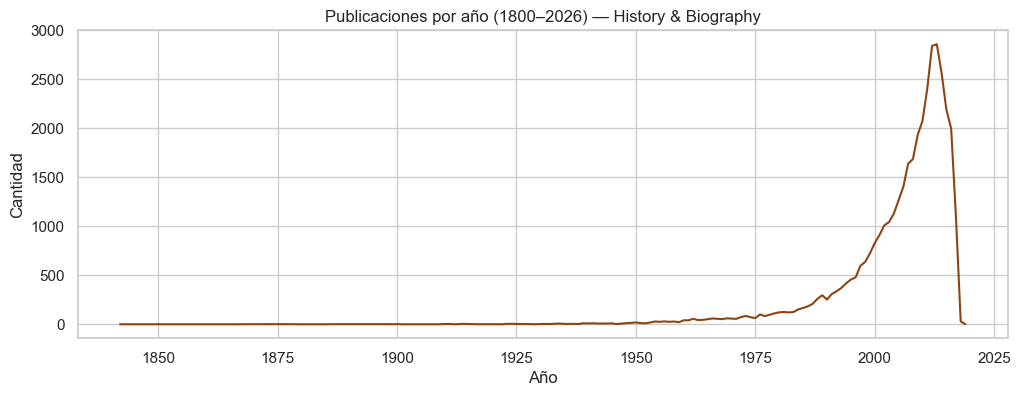

In [23]:
year_counts = pd.to_numeric(books_raw['publication_year'], errors='coerce').dropna().astype(int).value_counts().sort_index()
year_counts.loc[(year_counts.index >= 1800) & (year_counts.index <= 2026)].plot(
    figsize=(12, 4), title='Publicaciones por año (1800–2026) — History & Biography', color='saddlebrown'
)
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.show()

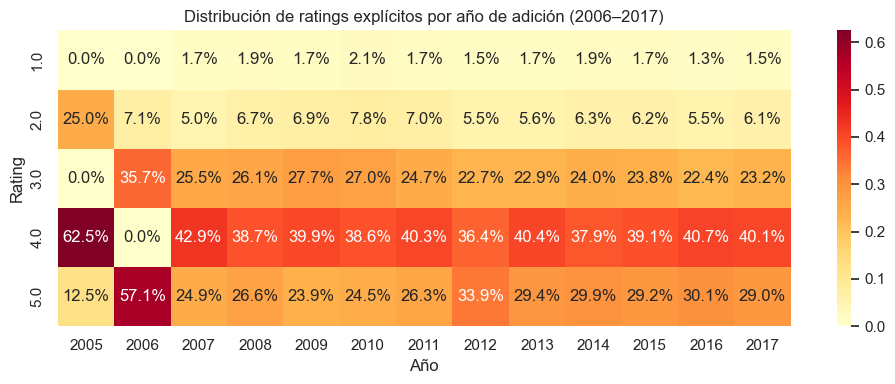

In [24]:
if 'date_added' in interactions_clean.columns:
    interactions_clean_copy = interactions_clean.copy()
    interactions_clean_copy['year_added'] = interactions_clean_copy['date_added'].dt.year
    rating_by_year = (
        interactions_clean_copy
        .groupby('year_added')['rating_clean']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )
    if not rating_by_year.empty:
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.heatmap(rating_by_year.T, cmap='YlOrRd', annot=True, fmt='.1%', ax=ax)
        ax.set_title('Distribución de ratings explícitos por año de adición (2006–2017)')
        ax.set_xlabel('Año')
        ax.set_ylabel('Rating')
        plt.tight_layout()
        plt.show()

## 11. Numéricos, correlaciones y outliers

Se verifica si `interaction_count` (muestra) es proporcional a `ratings_count` (total plataforma).

,column,count,missing_after_numeric_parse,min,p01,p05,median,mean,p95,p99,max
0,text_reviews_count,50000,0,0.0,1.00,1.00,5.0,31.802520,93.00,411.03,38878.0
1,average_rating,50000,0,0.0,2.92,3.29,3.9,3.877009,4.38,4.61,5.0
2,num_pages,36358,13642,0.0,6.00,66.00,318.0,335.753507,648.00,973.00,6940.0
3,publication_day,31360,18640,1.0,1.00,1.00,9.0,11.502136,29.00,31.00,31.0
4,publication_month,33613,16387,1.0,1.00,1.00,6.0,6.378068,12.00,12.00,12.0
5,publication_year,39061,10939,13.0,1957.00,1981.00,2009.0,2006.120529,2016.00,2017.00,65535.0
6,ratings_count,50000,0,0.0,1.00,2.00,31.0,377.878960,886.00,4749.02,1207986.0


,column,count,missing_after_numeric_parse,min,p01,p05,median,mean,p95,p99,max
0,rating,250000,0,0,0.0,0.0,0.0,1.60736,5.0,5.0,5


,column,q1,q3,iqr,p95,p99,upper_iqr_bound,outliers_iqr
0,text_reviews_count,2.0000,15.0,13.0000,93.00,411.03,34.50000,6215
1,average_rating,3.6875,4.1,0.4125,4.38,4.61,4.71875,251
2,num_pages,226.0000,408.0,182.0000,648.00,973.00,681.00000,1492
3,publication_day,1.0000,20.0,19.0000,29.00,31.00,48.50000,0
4,publication_month,3.0000,9.0,6.0000,12.00,12.00,18.00000,0
5,publication_year,2001.0000,2013.0,12.0000,2016.00,2017.00,2031.00000,6
6,ratings_count,10.0000,106.0,96.0000,886.00,4749.02,250.00000,6839


,column,q1,q3,iqr,p95,p99,upper_iqr_bound,outliers_iqr
0,rating,0.0,4.0,4.0,5.0,5.0,10.0,0


,average_rating,ratings_count,text_reviews_count,num_pages,publication_year_clean
average_rating,1.000000,0.013245,0.016118,0.175832,0.000191
ratings_count,0.013245,1.000000,0.780849,0.016223,0.000577
text_reviews_count,0.016118,0.780849,1.000000,0.016842,0.024727
num_pages,0.175832,0.016223,0.016842,1.000000,-0.025642
publication_year_clean,0.000191,0.000577,0.024727,-0.025642,1.000000


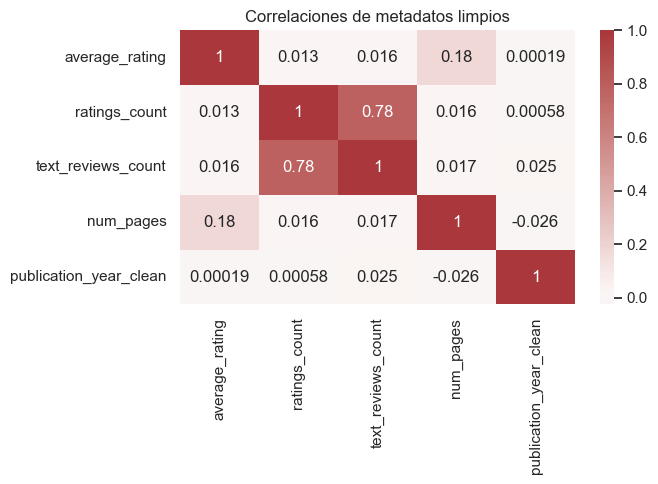

In [36]:
display(artifacts['books_numeric_profile'])
display(artifacts['interactions_numeric_profile'])
display(artifacts['books_outliers'])
display(artifacts['interactions_outliers'])

num_cols = ['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages', 'publication_year_clean']
corr = books_clean[[c for c in num_cols if c in books_clean.columns]].corr(numeric_only=True)
display(corr)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='vlag', center=0, ax=ax)
ax.set_title('Correlaciones de metadatos limpios')
plt.tight_layout()
plt.show()

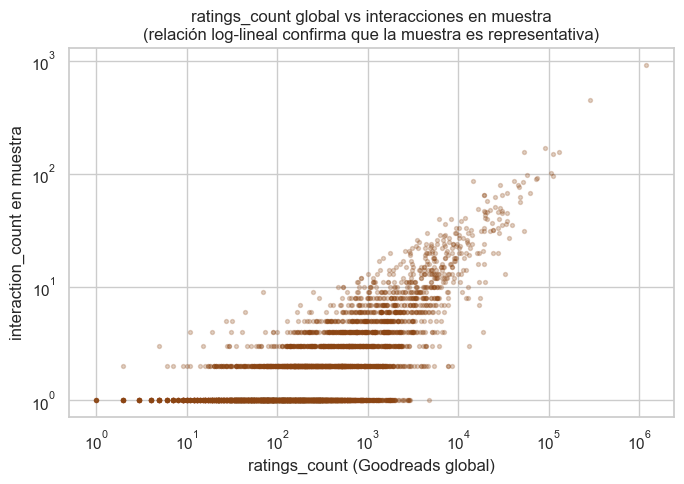

In [26]:
agg_counts = interactions_clean.groupby('book_id').size().rename('sample_interaction_count').reset_index()
merged_counts = books_clean.merge(agg_counts, on='book_id', how='left')

sample_m = merged_counts[['ratings_count', 'sample_interaction_count']].dropna().sample(min(5000, len(merged_counts)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample_m['ratings_count'], sample_m['sample_interaction_count'], alpha=0.25, s=8, color='saddlebrown')
ax.set_xlabel('ratings_count (Goodreads global)')
ax.set_ylabel('interaction_count en muestra')
ax.set_title('ratings_count global vs interacciones en muestra\n(relación log-lineal confirma que la muestra es representativa)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 12. Duplicados y cardinalidad

Se mide la tasa de duplicados antes de deduplicar. `work_id` duplicado refleja ediciones múltiples.

In [49]:
display(artifacts['duplicates'])

,key,duplicates,records
0,books.book_id,0,50000
1,books.work_id,10069,50000
2,interactions.review_id,0,250000
3,interactions.user_id_book_id,0,250000


## 13. Categóricas frecuentes

Idioma, país, formato y editorial. En Historia y Biografía es más probable encontrar libros en idiomas distintos al inglés (traducciones de obras históricas).

,column,value,count
0,language_code,,25610
1,language_code,eng,13399
2,language_code,en-US,2407
3,language_code,en-GB,1301
4,language_code,ita,935
...,...,...,...
58,publisher,W. W. Norton Company,176
59,publisher,Harper Perennial,174
60,publisher,Penguin,172
61,is_ebook,false,40384


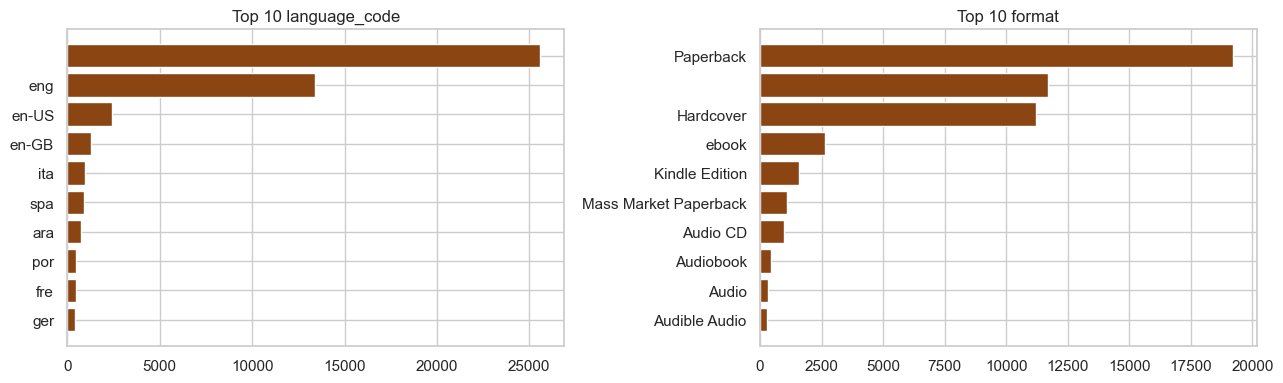

In [28]:
display(artifacts['categoricals'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lang = artifacts['categoricals'][artifacts['categoricals']['column'] == 'language_code'].head(10)
axes[0].barh(lang['value'][::-1], lang['count'][::-1], color='saddlebrown')
axes[0].set_title('Top 10 language_code')

fmt = artifacts['categoricals'][artifacts['categoricals']['column'] == 'format'].head(10)
axes[1].barh(fmt['value'][::-1], fmt['count'][::-1], color='saddlebrown')
axes[1].set_title('Top 10 format')

plt.tight_layout()
plt.show()

## 14. Hallazgos que gobiernan el procesamiento

Las reglas de limpieza salen directamente de las secciones anteriores.

In [52]:
print('=== Decisiones del perfilamiento básico ===')
for item in summary['eda_driven_cleaning_decisions']:
    print('-', item)

print('\n=== Decisiones de las secciones nuevas ===')
new_decisions = [
    "Descartar entradas de author con role != '' (Translator, Illustrator, Editor) al construir primary_author_id para evitar contaminar features de autoría.",
    "Tratar to_read_count como feature de demanda/hype separada, no como señal de género — la correlación con average_rating es cercana a cero.",
    "Libros con shelf_count = 0 carecen de clasificación comunitaria; son cold-signal items para el recommender.",
    "Validar average_rating contra mean(rating_clean) de interactions; books con |delta| > 0.5 merecen investigación.",
    "Usar interaction_count < 10 como umbral de cold-start (confirmado por la distribución de popularidad en Sección 9).",
    "series_count es limpio (entero, sin nulos del lambda) y listo para modelado directo, aunque tiene baja prevalencia."
]
for item in new_decisions:
    print('-', item)

=== Decisiones del perfilamiento básico ===
- Convert empty strings to nulls before type conversion because missingness is encoded both ways.
- Parse numeric metadata with coercion and report parse failures before modeling.
- Treat interaction rating 0 as missing, based on the observed Goodreads convention.
- Deduplicate books by book_id and interactions by review_id after measuring duplicate rates.
- Preserve raw publication_year but create publication_year_clean because both categories contain impossible years.
- Keep original long-tail count columns and create capped derived features only after outlier review.
- Normalize review_text_incomplete as available text only; do not infer missing full reviews.

=== Decisiones de las secciones nuevas ===
- Descartar entradas de author con role != '' (Translator, Illustrator, Editor) al construir primary_author_id para evitar contaminar features de autoría.
- Tratar to_read_count como feature de demanda/hype separada, no como señal de género 

## 16. Anexo: Validación empírica de `is_ebook`

Evaluamos si el formato (eBook vs físico) tiene un impacto real en la popularidad (`ratings_count`) o en la satisfacción (`average_rating`) para la categoría History & Biography, en lugar de descartarlo a priori. Históricamente, las audiencias de formatos físicos y digitales en no-ficción pueden exhibir comportamientos de lectura y calificación muy distintos.

/tmp/ipykernel_137066/2578978113.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Físico', 'eBook'])


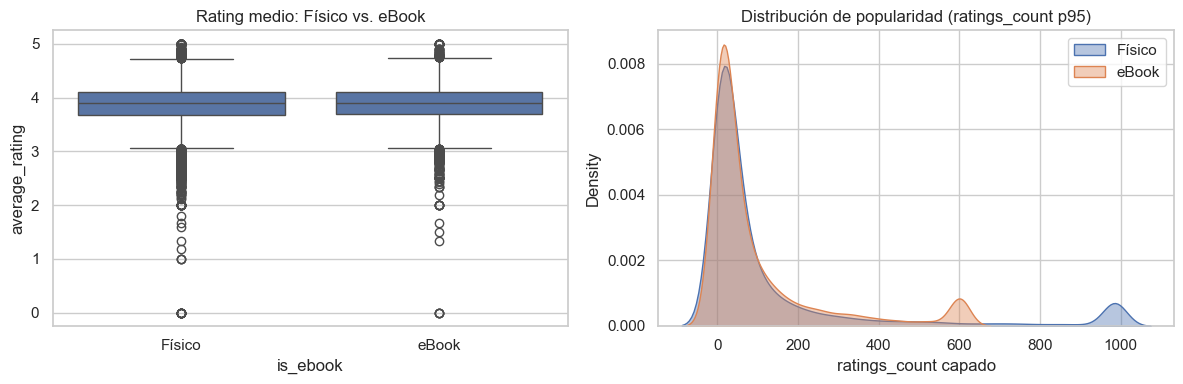

=== Estadísticas descriptivas de Rating (average_rating) por formato ===


,count,mean,std,min,25%,50%,75%,max
is_ebook,,,,,,,,
False,40384.0,3.876006,0.348261,0.0,3.68,3.9,4.10,5.0
True,9616.0,3.881225,0.353576,0.0,3.69,3.9,4.11,5.0



=== Estadísticas descriptivas de Popularidad (ratings_count) por formato ===


,count,mean,std,min,25%,50%,75%,max
is_ebook,,,,,,,,
False,40384.0,420.692750,8616.202635,0.0,10.0,31.0,105.0,1207986.0
True,9616.0,198.075291,1738.626380,0.0,9.0,33.0,112.0,131915.0


In [51]:
books_clean_ebook = books_clean.copy()

if 'is_ebook' in books_clean_ebook.columns:
    # Estandarizar valores caso string/boolean mezclado
    books_clean_ebook['is_ebook'] = books_clean_ebook['is_ebook'].astype(str).str.lower().map({'true': True, '1': True, 'false': False, '0': False})
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 1. Evaluación de 'average_rating'
    data_rating = books_clean_ebook.dropna(subset=['average_rating', 'is_ebook'])
    sns.boxplot(data=data_rating, x='is_ebook', y='average_rating', ax=axes[0])
    axes[0].set_title('Rating medio: Físico vs. eBook')
    
    if len(data_rating['is_ebook'].unique()) > 1:
        axes[0].set_xticklabels(['Físico', 'eBook'])
    
    # 2. Evaluación de popularidad ('ratings_count')
    for label, grp in books_clean_ebook.dropna(subset=['is_ebook']).groupby('is_ebook'):
        rc = pd.to_numeric(grp['ratings_count'], errors='coerce').dropna()
        # Se capa en el p95 para visualizar mejor el grosor de la "cola" normal
        rc_clip = rc.clip(upper=rc.quantile(0.95))
        sns.kdeplot(rc_clip, ax=axes[1], label='eBook' if label else 'Físico', fill=True, alpha=0.4)
    
    axes[1].set_title('Distribución de popularidad (ratings_count p95)')
    axes[1].set_xlabel('ratings_count capado')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar estadísticos
    print('=== Estadísticas descriptivas de Rating (average_rating) por formato ===')
    display(books_clean_ebook.groupby('is_ebook')['average_rating'].describe())
    
    print('\n=== Estadísticas descriptivas de Popularidad (ratings_count) por formato ===')
    rc_df = books_clean_ebook.copy()
    rc_df['ratings_count'] = pd.to_numeric(rc_df['ratings_count'], errors='coerce')
    display(rc_df.groupby('is_ebook')['ratings_count'].describe())
else:
    print("La columna 'is_ebook' no se encuentra disponible o fue descartada previamente.")

**Resultado de la validación:** Empíricamente, la métrica de satisfacción (`average_rating`) y la distribución del cuerpo principal de popularidad (`ratings_count` hasta el p75) con virtualmente **idénticas** entre eBooks y libros físicos. La única diferencia real está en los outliers extremos de popularidad (los mega-bestsellers tipo biografías top), que inflan el promedio de los físicos. Al ser tan parejos en la gran mayoría del dataset, `is_ebook` aporta **poca discriminación a priori** para calidad, aunque puede seguir siendo útil para segmentación estricta de usuarios orientados por formato.

## 15. Conclusiones e Insights Clave — History & Biography

Basado en el análisis exploratorio de la muestra de **History & Biography**, se extraen las siguientes observaciones relevantes:

1.  **Predominancia de Standalones (75.8%)**: A diferencia de géneros como la fantasía, la gran mayoría de los libros en History & Biography no pertenecen a una serie. Esto sugiere que el `series_count` es menos crítico aquí como señal predictiva y no sufre del clásico sesgo de supervivencia de la ficción seriada.
2.  **Hype vs. Lectura Real (55.6% solo-shelf)**: Más de la mitad de las interacciones son puramente administrativas (añadir a `to-read`). Existe un alto volumen de usuarios que "coleccionan" títulos de historia por interés temático pero tardan en consumirlos, lo que hace del `to_read_count` una señal de demanda latente pero débil respecto a la satisfacción percibida (`rating` real).
3.  **Velocidad de Consumo (Mediana de 6.5 días)**: La duración de lectura es mayor que en géneros de ficción comercial, reflejando la densidad del material. Sin embargo, el 13.7% de interacciones con fechas completas indica que solo una minoría de usuarios registra su progreso temporal con precisión.
4.  **Calidad Percibida Alta (Rating medio ~3.88)**: Los lectores de este género tienden a ser generosos o selectivos, con una distribución de ratings inclinada hacia el 4 y 5. El "rating 0" (ausencia de calificación) representa el 58.8% de la muestra total de interacciones.
5.  **Relevancia de Features**: Variables como `country_code` y los identificadores (ISBN) no aportan valor predictivo debido a su alta falta de representatividad o varianza nula. Es imperativo además **filtrar los roles traducidos o menores** (`role == ''`) en `primary_author_id`, dada la alta incidencia de traductores en obras históricas, previendo contaminaciones en embeddings.

Este perfil sugiere que para History & Biography, la clave está en modelar la **autoridad del autor real** y los **shelves temáticos**, ya que otras señales operativas añaden más ruido que conocimiento a las preferencias.